In [1]:
# imports
import torch
from model_trainer import load_model
from stock_dataloader import create_stock_dataloader
from metrics import direct_full_series, direct_category_window
from plots import plot_autoregressive_chain
import matplotlib.pyplot as plt

In [2]:
# load models
lstm_model = load_model('models/StockLSTM_ModelMini').eval()
transformer_model = load_model('models/StockTransformer_ModelMini').eval()
device = 'cuda' if torch.cuda.is_available() else 'cpu'
lstm_model.to(device)
transformer_model.to(device)

✅ Model loaded: models/StockLSTM_ModelMini
✅ Model loaded: models/StockTransformer_ModelMini


StockTransformer(
  (input_proj): Linear(in_features=1, out_features=64, bias=True)
  (pos_encoding): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (readout): Linear(in_features=64, out_features=1, bias=True)
  (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True

In [3]:
# load data

# Hyperparameters
SEQ_LEN = 1250          # default 1250; window for set of time-series data points
BATCH_SIZE = 128        # default 128; uses 25-30% of 12GB NVIDIA GeForce RTX 4070 GPU
STOCKS_PER_BUCKET = 5  # default 13; number of stocks per category bucket
TRAIN_PER_BUCKET = 3   # default 10; number of training stocks per category bucket

stock_csv = 'selected_stocks_data.csv'
metadata_csv = 'selected_stocks_quality.csv'
stock_dataloader = create_stock_dataloader(stock_csv, metadata_csv, seq_len=SEQ_LEN, batch_size=BATCH_SIZE,
                                           stocks_per_bucket=STOCKS_PER_BUCKET, train_per_bucket=TRAIN_PER_BUCKET)
eval_tickers = stock_dataloader['eval_tickers']
eval_stock_series = stock_dataloader['eval_raw_series']

Loading stock data...

Splitting top 5 stocks per category...
✅ Train: 15 tickers | Eval: 10 tickers

Creating training sequences...

✅ Data loaded: 15 train tickers, 10 eval tickers


In [4]:
# evaluation metrics

seq_len = SEQ_LEN      # same as categorization length
results = {}

for ticker, series in eval_stock_series.items():
    series = series.unsqueeze(0)
    lstm_full_mse, lstm_full_mae = direct_full_series(lstm_model, series, seq_len, device)
    lstm_cat_mse, lstm_cat_mae = direct_category_window(lstm_model, series, seq_len, device)
    transformer_full_mse, transformer_full_mae = direct_full_series(transformer_model, series, seq_len, device)
    transformer_cat_mse, transformer_cat_mae = direct_category_window(transformer_model, series, seq_len, device)
    results[ticker] = {
        'lstm_full_mse': lstm_full_mse,
        'lstm_full_mae': lstm_full_mae,
        'lstm_cat_mse': lstm_cat_mse,
        'lstm_cat_mae': lstm_cat_mae,
        'trans_full_mse': transformer_full_mse,
        'trans_full_mae': transformer_full_mae,
        'trans_cat_mse': transformer_cat_mse,
        'trans_cat_mae': transformer_cat_mae,
    }

c:\Users\jwcabot\.conda\envs\lstm-env\Lib\site-packages\torch\nn\modules\transformer.py:720: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  return torch._transformer_encoder_layer_fwd(


In [5]:
for ticker, metrics in results.items():
    print(f"Ticker: {ticker}")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.6f}")
    print()

Ticker: ARLP
  lstm_full_mse: 99.222453
  lstm_full_mae: 8.526654
  lstm_cat_mse: 185.188455
  lstm_cat_mae: 11.649997
  trans_full_mse: 122.999691
  trans_full_mae: 9.750735
  trans_cat_mse: 217.864097
  trans_cat_mae: 12.874464

Ticker: COKE
  lstm_full_mse: 1952.019828
  lstm_full_mae: 28.839745
  lstm_cat_mse: 5560.376909
  lstm_cat_mae: 65.821598
  trans_full_mse: 2033.182122
  trans_full_mae: 30.142490
  trans_cat_mse: 5746.020953
  trans_cat_mae: 67.213993

Ticker: FORR
  lstm_full_mse: 1081.606051
  lstm_full_mae: 31.406940
  lstm_cat_mse: 1099.863507
  lstm_cat_mae: 29.870222
  trans_full_mse: 1170.685240
  trans_full_mae: 32.790533
  trans_cat_mse: 1184.635199
  trans_cat_mae: 31.247388

Ticker: IART
  lstm_full_mse: 1573.669477
  lstm_full_mae: 35.444209
  lstm_cat_mse: 2223.966406
  lstm_cat_mae: 43.321356
  trans_full_mse: 1674.003370
  trans_full_mae: 36.823613
  trans_cat_mse: 2346.907363
  trans_cat_mae: 44.712721

Ticker: CME
  lstm_full_mse: 17075.095374
  lstm_full_m

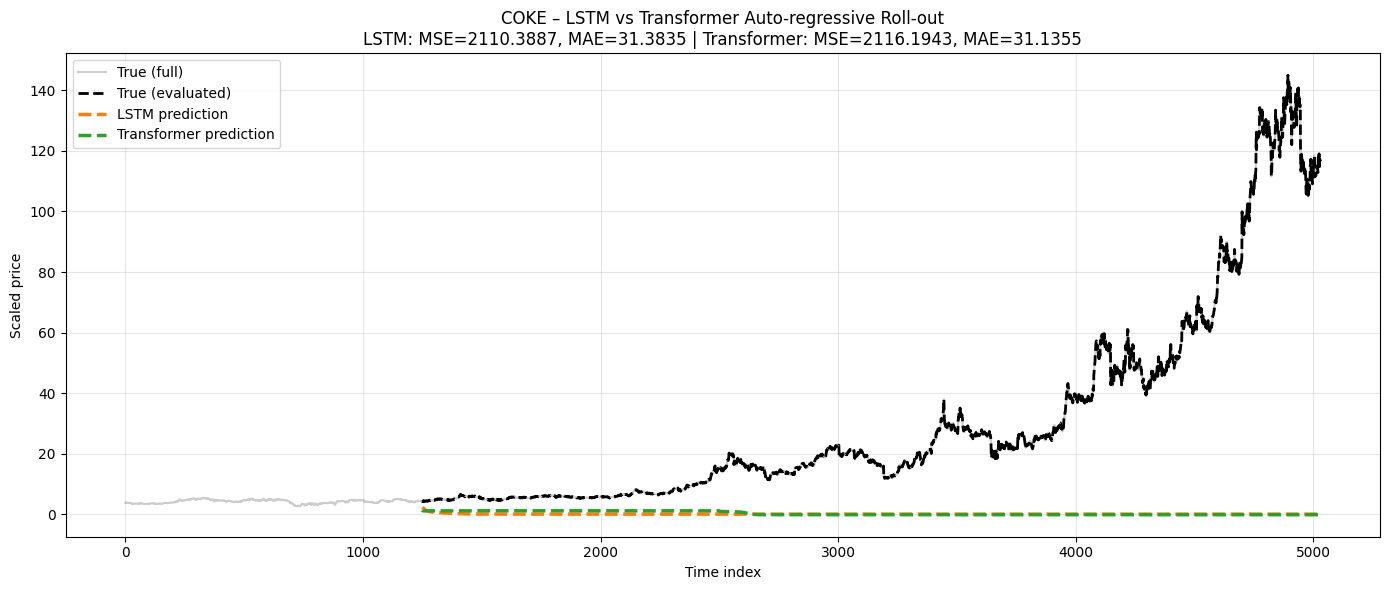

In [7]:
plot_tickers = ['COKE']

for ticker in plot_tickers:
    series = eval_stock_series[ticker]
    fig = plot_autoregressive_chain(lstm_model, transformer_model, ticker, series, seq_len, device)
    plt.show()